In [2]:
# STUDENT PLACEMENT PREDICTION
# Logistic Regression

# 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# 2. Load Dataset
df = pd.read_csv("cleaned_student_placement.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# 3. Check Dataset Information

print("\nDataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())


# 4. Remove Missing Values
df = df.dropna()
print("\nShape after removing missing values:", df.shape)

# 5. Define Target Column
target_column = "Placement"
X = df.drop(target_column, axis=1)
y = df[target_column]


# 6. Convert Target Yes/No to 1/0
if y.dtype == "object":
    y = y.astype(str).str.strip().str.lower()
    y = y.map({
        "yes": 1,
        "no": 0,
        "placed": 1,
        "not placed": 0
    })


# Check target
print("\nTarget values:")
print(y.value_counts())


# 7. Identify Numerical and Categorical Columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


# 8. Preprocessing
preprocessor = ColumnTransformer(transformers=[

        # Scale numerical data(
            "numerical",
            StandardScaler(),
            numerical_columns),
        # Convert categorical data into numbers
        ("categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns))



# 9. Create Logistic Regression Pipeline
model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",
            LogisticRegression(
                max_iter=1000 )))

# 10. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)





# 11. Train Model
model.fit(X_train, y_train)
print("\nModel trained successfully!")


# 12. Make Predictions
y_pred = model.predict(X_test)

# 13. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n================================")
print("MODEL ACCURACY")
print("================================")

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


# 14. Classification Report
print("\n================================")
print("CLASSIFICATION REPORT")
print("================================")

print(classification_report(y_test,y_pred))


# 15. Confusion Matrix
print("\n================================")
print("CONFUSION MATRIX")
print("================================")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)




Dataset loaded successfully!
Shape: (10000, 12)

First 5 rows:
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79

KeyError: "['Placement'] not found in axis"

In [3]:
print("Column names in your dataset:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Column names in your dataset:
['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']

First 5 rows:
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4     

In [4]:
target_column = "PlacementStatus"

Column names:
0 : 'StudentID'
1 : 'CGPA'
2 : 'Internships'
3 : 'Projects'
4 : 'Workshops/Certifications'
5 : 'AptitudeTestScore'
6 : 'SoftSkillsRating'
7 : 'ExtracurricularActivities'
8 : 'PlacementTraining'
9 : 'SSC_Marks'
10 : 'HSC_Marks'
11 : 'PlacementStatus'

First 5 rows:
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85  

In [6]:
print("Rows and Columns:", df.shape)
print("Columns:", df.columns.tolist())

Rows and Columns: (10000, 12)
Columns: ['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']


In [7]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus               object
dtype: object

Missing values:
StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64


In [8]:
# Display first five rows
print(df.head())

# Check dataset dimensions
print("Dataset Shape:", df.shape)

# Check data types and structure
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Check placement distribution
print(df["Placed"].value_counts())

   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1               Yes         78         82   

KeyError: 'Placed'

In [9]:
# ============================================
# 16. BASELINE BENCHMARK
# ============================================

from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

print("\n================================")
print("BASELINE BENCHMARK")
print("================================")

print("Dummy Classifier Accuracy:",
      dummy_accuracy)

print("Dummy Classifier Accuracy (%):",
      dummy_accuracy * 100)

print("\nLogistic Regression Accuracy:",
      accuracy)

print("Logistic Regression Accuracy (%):",
      accuracy * 100)a

NameError: name 'X_train' is not defined

In [1]:
df = pd.read_csv("cleaned_student_placement.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("cleaned_student_placement.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (10000, 12)


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [4]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info() 
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())
print("\nPlacement Status Distribution:")
print(df["PlacementStatus"].value_counts())

Column Names:
['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks             

In [5]:
X = df.drop(["StudentID", "PlacementStatus"], axis=1)

y = df["PlacementStatus"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.value_counts())

Features (X):
['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks']

Target (y):
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64


In [6]:
y = y.map({
    "Placed": 1,
    "NotPlaced": 0
})

print(y.value_counts())

PlacementStatus
0    5803
1    4197
Name: count, dtype: int64


In [7]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']

Categorical Features:
['ExtracurricularActivities', 'PlacementTraining']


In [8]:
#Splitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [9]:
#preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [10]:
#Baseline model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Baseline model created successfully!")



Baseline model created successfully!


In [11]:
#train and Prediction
baseline_model.fit(X_train, y_train)
print("Baseline Logistic Regression trained successfully!")

y_pred = baseline_model.predict(X_test)

print("Predictions generated successfully!")

Baseline Logistic Regression trained successfully!
Predictions generated successfully!


In [12]:
#Baseline metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== WEEK 3 BASELINE RESULTS =====")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

===== WEEK 3 BASELINE RESULTS =====
Accuracy : 80.85 %
Precision: 76.95 %
Recall   : 77.59 %
F1 Score : 77.27 %


In [13]:
#Classification Report  and confusion matrics
print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)
cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Not Placed       0.84      0.83      0.83      1161
      Placed       0.77      0.78      0.77       839

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000


===== CONFUSION MATRIX =====
[[966 195]
 [188 651]]


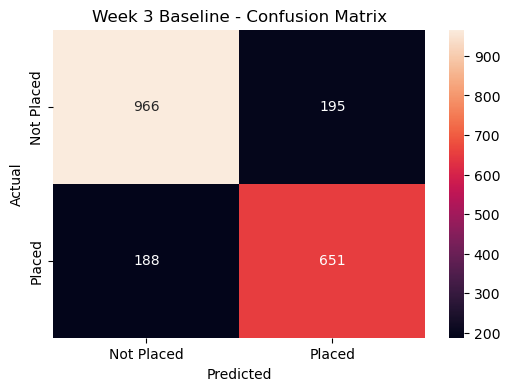

In [14]:
#Visialisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Week 3 Baseline - Confusion Matrix")
plt.show()

In [15]:
#Week 3 ended at all then for now week 4 processing
print("Numerical Features:")
print(list(numeric_features))

Numerical Features:
['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']


In [16]:
#interation feature
from sklearn.preprocessing import PolynomialFeatures

interaction_transformer = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

print("Interaction feature transformer created successfully!")

Interaction feature transformer created successfully!


In [17]:
#Week 4 pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

week4_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("interaction", PolynomialFeatures(
                    degree=2,
                    interaction_only=True,
                    include_bias=False
                )),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Week 4 feature engineering pipeline created!")

Week 4 feature engineering pipeline created!


In [18]:
#Training of improved logistic regression
week4_lr = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", LogisticRegression(max_iter=2000))
    ]
)
print("Week 4 Logistic Regression created!")

week4_lr.fit(X_train, y_train)
print("Week 4 Logistic Regression trained successfully!")

y_pred_week4 = week4_lr.predict(X_test)
print("Predictions generated successfully!")

accuracy_week4 = accuracy_score(y_test, y_pred_week4)
precision_week4 = precision_score(y_test, y_pred_week4)
recall_week4 = recall_score(y_test, y_pred_week4)
f1_week4 = f1_score(y_test, y_pred_week4)

print("===== WEEK 4 FEATURE ENGINEERED MODEL =====")
print("Accuracy :", round(accuracy_week4 * 100, 2), "%")
print("Precision:", round(precision_week4 * 100, 2), "%")
print("Recall   :", round(recall_week4 * 100, 2), "%")
print("F1 Score :", round(f1_week4 * 100, 2), "%")

Week 4 Logistic Regression created!
Week 4 Logistic Regression trained successfully!
Predictions generated successfully!
===== WEEK 4 FEATURE ENGINEERED MODEL =====
Accuracy : 80.25 %
Precision: 77.14 %
Recall   : 75.21 %
F1 Score : 76.16 %


In [20]:
#Comparision of week 3 and week 4
comparison = pd.DataFrame({
    "Model": [
        "Week 3 Baseline",
        "Week 4 Feature Engineered"
    ],
    
    "Accuracy": [
        accuracy,
        accuracy_week4
    ],
    
    "Precision": [
        precision,
        precision_week4
    ],
    
    "Recall": [
        recall,
        recall_week4
    ],
    
    "F1 Score": [
        f1,
        f1_week4
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 3 Baseline,0.8085,0.769504,0.775924,0.772700
1,Week 4 Feature Engineered,0.8025,0.771394,0.752086,0.761617


[[974 187]
 [208 631]]


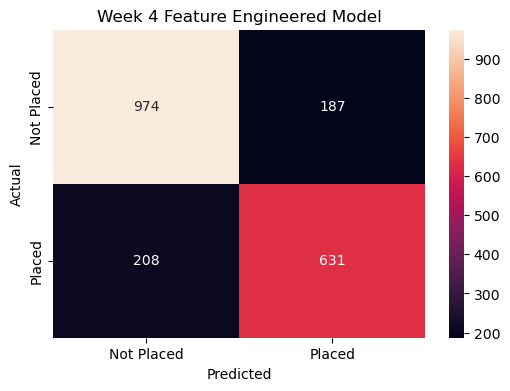

In [22]:
#Confusion matrics for week 4
cm_week4 = confusion_matrix(y_test, y_pred_week4)
print(cm_week4)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_week4,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Week 4 Feature Engineered Model")

plt.show()

In [23]:
#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

print("Parameter grid created:")
print(param_grid_lr)

grid_lr = GridSearchCV(
    estimator=week4_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV created successfully!")

grid_lr.fit(X_train, y_train)

Parameter grid created:
{'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__solver': ['liblinear', 'lbfgs']}
GridSearchCV created successfully!
Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step..._iter=2000))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [24]:
print("Best Parameters:")
print(grid_lr.best_params_)
print("Best Cross-Validation F1 Score:")
print(round(grid_lr.best_score_, 4))

Best Parameters:
{'classifier__C': 1, 'classifier__solver': 'liblinear'}
Best Cross-Validation F1 Score:
0.7567


In [25]:
#Calculating the results
tuned_lr_accuracy = accuracy_score(y_test, y_pred_tuned_lr)
tuned_lr_precision = precision_score(y_test, y_pred_tuned_lr)
tuned_lr_recall = recall_score(y_test, y_pred_tuned_lr)
tuned_lr_f1 = f1_score(y_test, y_pred_tuned_lr)

print("===== TUNED LOGISTIC REGRESSION =====")
print("Accuracy :", round(tuned_lr_accuracy * 100, 2), "%")
print("Precision:", round(tuned_lr_precision * 100, 2), "%")
print("Recall   :", round(tuned_lr_recall * 100, 2), "%")
print("F1 Score :", round(tuned_lr_f1 * 100, 2), "%")

NameError: name 'y_pred_tuned_lr' is not defined

In [26]:
# Get the best model found by GridSearchCV
best_lr = grid_lr.best_estimator_

# Make predictions on the test data
y_pred_tuned_lr = best_lr.predict(X_test)

print("Tuned Logistic Regression predictions generated successfully!")

Tuned Logistic Regression predictions generated successfully!


In [27]:
# Calculating the results

tuned_lr_accuracy = accuracy_score(y_test, y_pred_tuned_lr)
tuned_lr_precision = precision_score(y_test, y_pred_tuned_lr)
tuned_lr_recall = recall_score(y_test, y_pred_tuned_lr)
tuned_lr_f1 = f1_score(y_test, y_pred_tuned_lr)

print("===== TUNED LOGISTIC REGRESSION =====")
print("Accuracy :", round(tuned_lr_accuracy * 100, 2), "%")
print("Precision:", round(tuned_lr_precision * 100, 2), "%")
print("Recall   :", round(tuned_lr_recall * 100, 2), "%")
print("F1 Score :", round(tuned_lr_f1 * 100, 2), "%")

===== TUNED LOGISTIC REGRESSION =====
Accuracy : 80.2 %
Precision: 77.05 %
Recall   : 75.21 %
F1 Score : 76.12 %


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Week 3 Baseline",
        "Week 4 Feature Engineered",
        "Week 4 Tuned Logistic Regression"
    ],

    "Accuracy": [
        accuracy,
        accuracy_week4,
        tuned_lr_accuracy
    ],

    "Precision": [
        precision,
        precision_week4,
        tuned_lr_precision
    ],

    "Recall": [
        recall,
        recall_week4,
        tuned_lr_recall
    ],

    "F1 Score": [
        f1,
        f1_week4,
        tuned_lr_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 3 Baseline,0.8085,0.769504,0.775924,0.772700
1,Week 4 Feature Engineered,0.8025,0.771394,0.752086,0.761617
2,Week 4 Tuned Logistic Regression,0.8020,0.770452,0.752086,0.761158


In [29]:
#Now Random Forest
from sklearn.ensemble import RandomForestClassifier
print("Random Forest imported successfully!")

Random Forest imported successfully!


In [30]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [31]:
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

y_pred_rf = rf_model.predict(X_test)
print("Random Forest predictions generated!")

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("===== RANDOM FOREST =====")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

Random Forest trained successfully!
Random Forest predictions generated!
===== RANDOM FOREST =====
Accuracy : 79.45 %
Precision: 76.88 %
Recall   : 72.94 %
F1 Score : 74.86 %


In [32]:
#tuning of random forest
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10]
}

print("Random Forest parameter grid created!")
print(rf_param_grid)

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("Random Forest GridSearchCV created!")

grid_rf.fit(X_train, y_train)
print("===== BEST RANDOM FOREST PARAMETERS =====")
print(grid_rf.best_params_)
print("===== BEST CROSS-VALIDATION F1 SCORE =====")
print(round(grid_rf.best_score_, 4))
best_rf = grid_rf.best_estimator_

print("Best Random Forest model selected!")
y_pred_tuned_rf = best_rf.predict(X_test)

print("Tuned Random Forest predictions generated!")

Random Forest parameter grid created!
{'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10, 20], 'classifier__min_samples_split': [2, 5, 10]}
Random Forest GridSearchCV created!
Fitting 5 folds for each of 18 candidates, totalling 90 fits
===== BEST RANDOM FOREST PARAMETERS =====
{'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
===== BEST CROSS-VALIDATION F1 SCORE =====
0.7457
Best Random Forest model selected!
Tuned Random Forest predictions generated!


In [34]:
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)
tuned_rf_precision = precision_score(y_test, y_pred_tuned_rf)
tuned_rf_recall = recall_score(y_test, y_pred_tuned_rf)
tuned_rf_f1 = f1_score(y_test, y_pred_tuned_rf)

print("===== TUNED RANDOM FOREST =====")
print("Accuracy :", round(tuned_rf_accuracy * 100, 2), "%")
print("Precision:", round(tuned_rf_precision * 100, 2), "%")
print("Recall   :", round(tuned_rf_recall * 100, 2), "%")
print("F1 Score :", round(tuned_rf_f1 * 100, 2), "%")

===== TUNED RANDOM FOREST =====
Accuracy : 79.95 %
Precision: 77.31 %
Recall   : 73.9 %
F1 Score : 75.56 %


In [35]:
#SVM NOW
from sklearn.svm import SVC
svm_model = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", SVC())
    ]
)
print("SVM model created successfully!")
svm_model.fit(X_train, y_train)
print("SVM trained successfully!")

y_pred_svm = svm_model.predict(X_test)
print("SVM predictions generated!")

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("===== DEFAULT SVM =====")
print("Accuracy :", round(svm_accuracy * 100, 2), "%")
print("Precision:", round(svm_precision * 100, 2), "%")
print("Recall   :", round(svm_recall * 100, 2), "%")
print("F1 Score :", round(svm_f1 * 100, 2), "%")

SVM model created successfully!
SVM trained successfully!
SVM predictions generated!
===== DEFAULT SVM =====
Accuracy : 80.65 %
Precision: 77.83 %
Recall   : 75.33 %
F1 Score : 76.56 %


In [39]:
#SVM hyper parameter tuning
svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"]
}

print("SVM parameter grid created!")
print(svm_param_grid)

grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("SVM GridSearchCV created!")
grid_svm.fit(X_train, y_train)
print("===== BEST SVM PARAMETERS =====")
print(grid_svm.best_params_)
print("===== BEST SVM CROSS-VALIDATION F1 =====")
print(round(grid_svm.best_score_, 4))
best_svm = grid_svm.best_estimator_
print("Best SVM model selected!")
y_pred_tuned_svm = best_svm.predict(X_test)
print("Tuned SVM predictions generated!")

tuned_svm_accuracy = accuracy_score(y_test, y_pred_tuned_svm)
tuned_svm_precision = precision_score(y_test, y_pred_tuned_svm)
tuned_svm_recall = recall_score(y_test, y_pred_tuned_svm)
tuned_svm_f1 = f1_score(y_test, y_pred_tuned_svm)

print("===== TUNED SVM =====")
print("Accuracy :", round(tuned_svm_accuracy * 100, 2), "%")
print("Precision:", round(tuned_svm_precision * 100, 2), "%")
print("Recall   :", round(tuned_svm_recall * 100, 2), "%")
print("F1 Score :", round(tuned_svm_f1 * 100, 2), "%")

SVM parameter grid created!
{'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf'], 'classifier__gamma': ['scale', 'auto']}
SVM GridSearchCV created!
Fitting 5 folds for each of 12 candidates, totalling 60 fits
===== BEST SVM PARAMETERS =====
{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
===== BEST SVM CROSS-VALIDATION F1 =====
0.7554
Best SVM model selected!
Tuned SVM predictions generated!
===== TUNED SVM =====
Accuracy : 80.15 %
Precision: 77.15 %
Recall   : 74.85 %
F1 Score : 75.98 %


In [40]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = Pipeline(
    steps=[
        ("preprocessor", week4_preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)

print("KNN model created successfully!")
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("===== DEFAULT KNN =====")
print("Accuracy :", round(knn_accuracy * 100, 2), "%")
print("Precision:", round(knn_precision * 100, 2), "%")
print("Recall   :", round(knn_recall * 100, 2), "%")
print("F1 Score :", round(knn_f1 * 100, 2), "%")

KNN model created successfully!
===== DEFAULT KNN =====
Accuracy : 77.6 %
Precision: 74.29 %
Recall   : 71.28 %
F1 Score : 72.75 %


In [41]:
#KNN Hypermeter tuning
knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

print("KNN parameter grid created!")
print(knn_param_grid)

grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("KNN GridSearchCV created!")

grid_knn.fit(X_train, y_train)
print("===== BEST KNN PARAMETERS =====")
print(grid_knn.best_params_)
print("===== BEST KNN CROSS-VALIDATION F1 =====")
print(round(grid_knn.best_score_, 4))
best_knn = grid_knn.best_estimator_
print("Best KNN model selected!")
y_pred_tuned_knn = best_knn.predict(X_test)
print("Tuned KNN predictions generated!")

tuned_knn_accuracy = accuracy_score(y_test, y_pred_tuned_knn)
tuned_knn_precision = precision_score(y_test, y_pred_tuned_knn)
tuned_knn_recall = recall_score(y_test, y_pred_tuned_knn)
tuned_knn_f1 = f1_score(y_test, y_pred_tuned_knn)

print("===== TUNED KNN =====")
print("Accuracy :", round(tuned_knn_accuracy * 100, 2), "%")
print("Precision:", round(tuned_knn_precision * 100, 2), "%")
print("Recall   :", round(tuned_knn_recall * 100, 2), "%")
print("F1 Score :", round(tuned_knn_f1 * 100, 2), "%")

KNN parameter grid created!
{'classifier__n_neighbors': [3, 5, 7, 9, 11, 15], 'classifier__weights': ['uniform', 'distance'], 'classifier__metric': ['euclidean', 'manhattan']}
KNN GridSearchCV created!
Fitting 5 folds for each of 24 candidates, totalling 120 fits
===== BEST KNN PARAMETERS =====
{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 15, 'classifier__weights': 'uniform'}
===== BEST KNN CROSS-VALIDATION F1 =====
0.7417
Best KNN model selected!
Tuned KNN predictions generated!
===== TUNED KNN =====
Accuracy : 79.35 %
Precision: 75.24 %
Recall   : 75.69 %
F1 Score : 75.46 %


In [42]:
final_results = pd.DataFrame({
    "Model": [
        "Week 3 Baseline Logistic Regression",
        "Feature Engineered Logistic Regression",
        "Tuned Logistic Regression",
        "Default Random Forest",
        "Tuned Random Forest",
        "Default SVM",
        "Tuned SVM",
        "Default KNN",
        "Tuned KNN"
    ],

    "Accuracy": [
        accuracy,
        accuracy_week4,
        tuned_lr_accuracy,
        rf_accuracy,
        tuned_rf_accuracy,
        svm_accuracy,
        tuned_svm_accuracy,
        knn_accuracy,
        tuned_knn_accuracy
    ],

    "Precision": [
        precision,
        precision_week4,
        tuned_lr_precision,
        rf_precision,
        tuned_rf_precision,
        svm_precision,
        tuned_svm_precision,
        knn_precision,
        tuned_knn_precision
    ],

    "Recall": [
        recall,
        recall_week4,
        tuned_lr_recall,
        rf_recall,
        tuned_rf_recall,
        svm_recall,
        tuned_svm_recall,
        knn_recall,
        tuned_knn_recall
    ],

    "F1 Score": [
        f1,
        f1_week4,
        tuned_lr_f1,
        rf_f1,
        tuned_rf_f1,
        svm_f1,
        tuned_svm_f1,
        knn_f1,
        tuned_knn_f1
    ]
})

final_results

final_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 3 Baseline Logistic Regression,0.8085,0.769504,0.775924,0.772700
1,Default SVM,0.8065,0.778325,0.753278,0.765597
2,Feature Engineered Logistic Regression,0.8025,0.771394,0.752086,0.761617
3,Tuned Logistic Regression,0.8020,0.770452,0.752086,0.761158
4,Tuned SVM,0.8015,0.771499,0.748510,0.759831
5,Tuned Random Forest,0.7995,0.773067,0.738975,0.755637
6,Tuned KNN,0.7935,0.752370,0.756853,0.754605
7,Default Random Forest,0.7945,0.768844,0.729440,0.748624
8,Default KNN,0.7760,0.742857,0.712753,0.727494


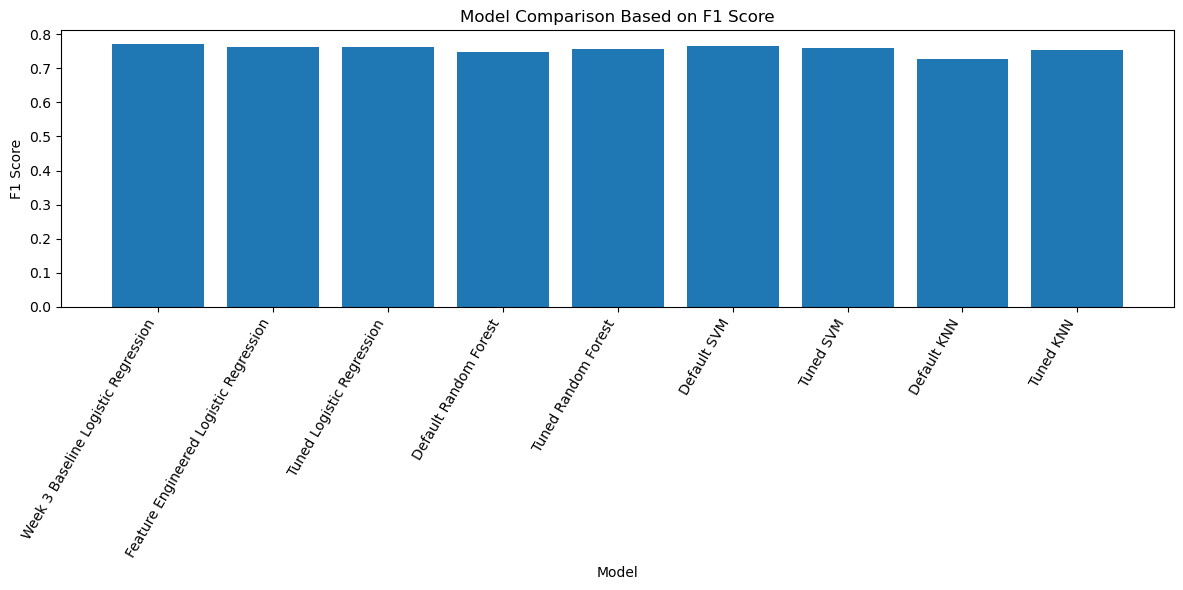

In [43]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model Comparison Based on F1 Score")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()

plt.show()

===== FINAL MODEL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Not Placed       0.84      0.83      0.83      1161
      Placed       0.77      0.78      0.77       839

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000

===== FINAL CONFUSION MATRIX =====
[[966 195]
 [188 651]]


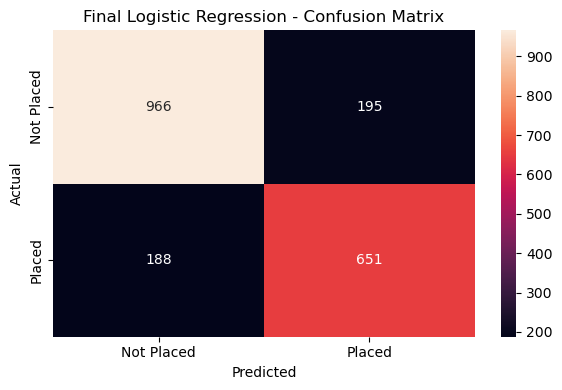

In [44]:
print("===== FINAL MODEL CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)

final_cm = confusion_matrix(y_test, y_pred)

print("===== FINAL CONFUSION MATRIX =====")
print(final_cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

ROC-AUC Score: 0.8837


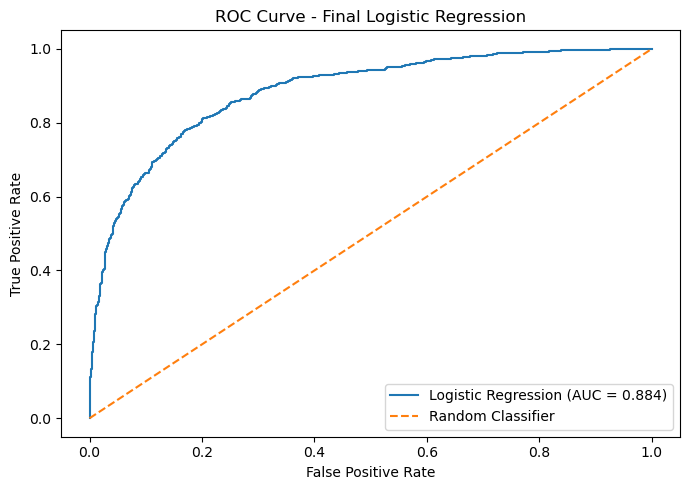

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = baseline_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression")

plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Get the trained Logistic Regression model
lr_model = baseline_model.named_steps["classifier"]

# Get the preprocessing transformer
preprocessor_fitted = baseline_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = lr_model.coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Importance
10,cat__PlacementTraining_No,-0.661943,0.661943
4,num__AptitudeTestScore,0.610339,0.610339
8,cat__ExtracurricularActivities_No,-0.585779,0.585779
6,num__SSC_Marks,0.282377,0.282377
5,num__SoftSkillsRating,0.263395,0.263395
0,num__CGPA,0.257472,0.257472
2,num__Projects,0.254510,0.254510
7,num__HSC_Marks,0.221629,0.221629
11,cat__PlacementTraining_Yes,0.221419,0.221419
9,cat__ExtracurricularActivities_Yes,0.145255,0.145255


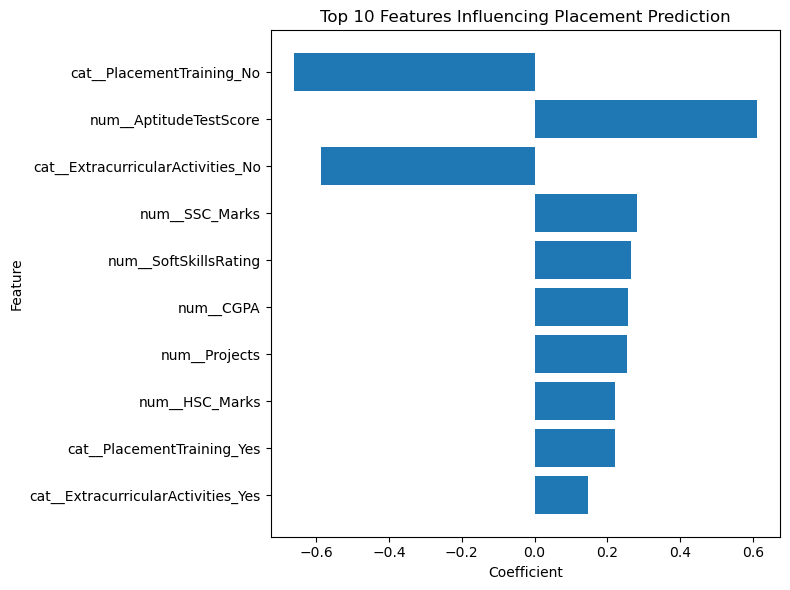

In [47]:
top_features = feature_importance.head(10).sort_values(
    by="Absolute_Importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Placement Prediction")

plt.tight_layout()
plt.show()